In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tickers = [
    "NVDA", "AAPL", "MSFT", "GOOGL", "AMZN", "META", "AVGO", "TSLA", "ANET", "LLY", 
    "JPM", "V", "UNH", "MA", "COST", "XOM", "WMT", "PG", "JNJ", "HD", 
    "ABBV", "BAC", "KO", "CRM", "ORCL", "CSCO", "CVX", "ADBE", "ACN", "NFLX", 
    "MRK", "PEP", "LIN", "AMD", "TMO", "ABT", "WFC", "DIS", "DHR", "MCD", 
    "INTU", "TXN", "VZ", "PM", "QCOM", "PGR", "CAT", "SPGI", "IBM", "NEE", 
    "AXP", "AMGN", "HON", "LOW", "MS", "RTX", "GE", "UNP", "GS", "ISRG", 
    "BLK", "INTC", "UBER", "COP", "BKNG", "T", "TJX", "VRTX", "SYK", "ETN"
]

print(f"Total tickers: {len(tickers)}")
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")


Total tickers: 70


[*********************100%***********************]  70 of 70 completed


In [3]:
close = data["Close"]
returns = close.pct_change()
returns.head()
print(close.shape)
print(returns.shape)
min_obs = int(0.9 * len(returns))
returns = returns.dropna(axis=1, thresh=min_obs)
returns = returns.dropna()
print(returns.shape)

(2516, 70)
(2516, 70)
(2515, 69)


Tickers represent companies whos stock we are intrested in, we extract 10 years worth of data (Close, High, Low, Open, Volume) with the Date as index.

Returns is the percent change from the previous day's close value to the next day's close value. Returns is checked for null values, the only one being the first row (for the 4 tickers) since there is no previous day to calculate percentage change from. The first row is then dropped.

A ticker (axis 1) must have at least 90% of days worth of data over the last 10 years or else the ticker return data is dropped.

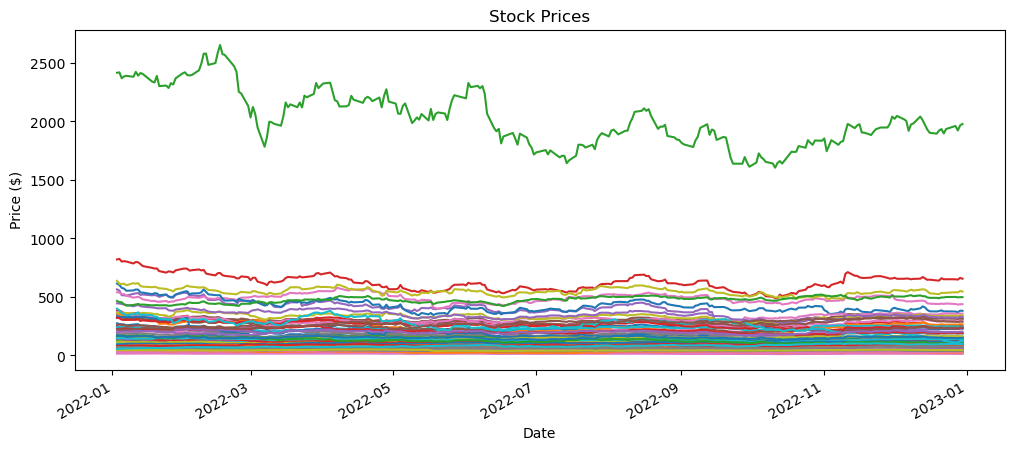

<Figure size 2000x500 with 0 Axes>

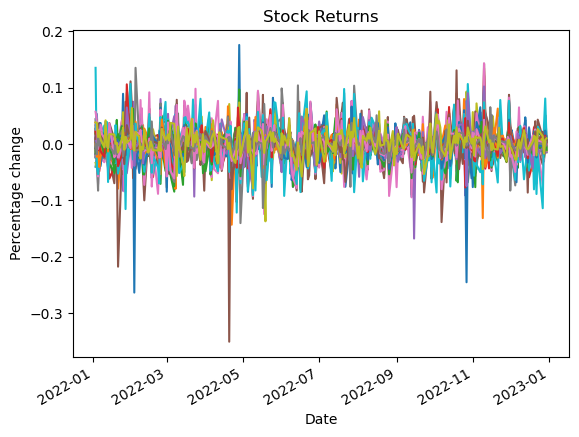

In [4]:
close_2022 = close.loc["2022"]
returns_2022 = returns.loc["2022"]

close_2022.plot(figsize=(12,5))
plt.ylabel("Price ($)")
plt.title("Stock Prices")
plt.legend().set_visible(False)

plt.figure(figsize=(20,5))
returns_2022.plot()
plt.ylabel("Percentage change")
plt.title("Stock Returns")
plt.legend().set_visible(False)

Stock prices for all tickers are plotted in the Jan 2022 to Jan 2023 time period. Ticker legend removed as list is 70 long and confuses figure.

Ticker
NVDA    277.950566
AMD      45.239699
AVGO     30.390668
ANET     28.214422
TSLA     27.621174
NFLX     17.880554
AMZN     14.222093
LLY      13.332081
PGR      11.383280
MSFT     10.497481
Name: 2024-12-31 00:00:00, dtype: float64

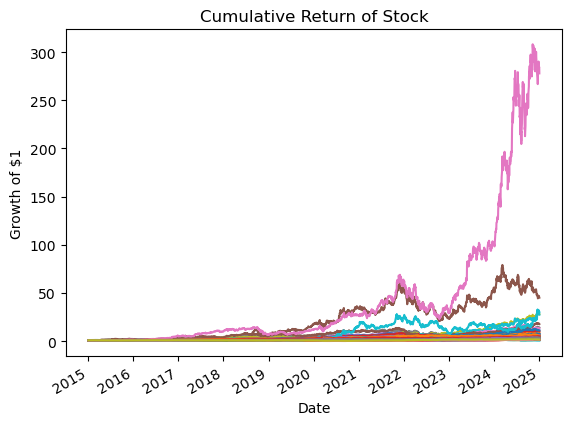

In [5]:
cum_returns = (returns + 1).cumprod()

cum_returns.plot()
plt.title("Cumulative Return of Stock")
plt.ylabel("Growth of $1")
plt.legend().set_visible(False)


cum_values = cum_returns.loc["2024-12-31"]
cum_values.sort_values(ascending=False).head(10)

Cumulitive returns show how a $1 investment at the start date grows using the daily return rate to calcuate daily changes.

Top 5 highest returns over a 10 year period are shown in head of dataset. Identifying the best performing companies over the last 10 years.

In [6]:
mean_returns = returns.mean()
volatility = returns.std()

annual_return = mean_returns * 252
annual_volatility = volatility * np.sqrt(252)

annual_perf = pd.DataFrame({"Annual Return": annual_return, "Annual Volatility": annual_volatility})

annual_perf.sort_values("Annual Return", ascending=False)

,Annual Return,Annual Volatility
Ticker,,
NVDA,0.681307,0.486071
AMD,0.550305,0.586478
TSLA,0.495369,0.571620
ANET,0.424418,0.423042
AVGO,0.411970,0.374250
...,...,...
KO,0.086883,0.177859
JNJ,0.076514,0.180528
DIS,0.064184,0.278397


Mean returns is just the avergae of daily returns, volatilty is the standard deviation in thedaily returns (i.e. a measure of its fluctutations).

Annual returns is how much an investment grows in one year (exactly) on average.
Annual volatilty is how much a stock's returns flucatuate in a year (i.e. risk).

In [7]:
close.to_parquet("close_prices.parquet")
returns.to_parquet("daily_returns.parquet")
annual_perf.to_parquet("annual_summary.parquet")